In [12]:
from google.colab import files
files.upload()   # upload kaggle.json here


Saving kaggle .json to kaggle .json


{'kaggle .json': b'{"username":"mohitsoni999","key":"2619a09ba5784bbf025e9d2db94a5e9b"}'}

In [13]:
# set up kaggle and download dataset (runs in Colab)
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -q
!unzip -q chest-xray-pneumonia.zip -d /content/
!ls -la /content/chest_xray


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
replace /content/chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
a
total 28
drwxr-xr-x 7 root root 4096 Jul  9 11:01 .
drwxr-xr-x 1 root root 4096 Jul  9 10:56 ..
drwxr-xr-x 5 root root 4096 Jul  9 11:01 chest_xray
drwxr-xr-x 3 root root 4096 Jul  9 11:01 __MACOSX
drwxr-xr-x 4 root root 4096 Jul  9 11:01 test
drwxr-xr-x 4 root root 4096 Jul  9 11:01 train
drwxr-xr-x 4 root root 4096 Jul  9 11:01 val


In [14]:
DATA_DIR = "/content/chest_xray"


In [15]:
# Cell 1: install dependencies (run once)
!pip install --upgrade pip
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q matplotlib scikit-learn pillow tqdm gradio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [5]:
# Cell 2: config and imports
import os
import time
import copy
import math
import json
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

# CONFIG - edit these to match your dataset / model preferences
DATA_DIR = "/content/chest_xray"       # path to chest_xray folder OR a folder with class subfolders
INPUT_SIZE = (224, 224)                # common: (224,224) - change if needed
BATCH_SIZE = 16
NUM_WORKERS = 2
EPOCHS = 6
LEARNING_RATE = 1e-4
NUM_CLASSES = 2                        # Normal vs Pneumonia
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [17]:
# Cell 3: dataset & dataloaders (ImageFolder style)
from torchvision.datasets import ImageFolder

train_dir = os.path.join(DATA_DIR, "train")
val_dir   = os.path.join(DATA_DIR, "val")
test_dir  = os.path.join(DATA_DIR, "test")

# Fallback if dataset is not split; assume DATA_DIR has class subfolders
use_fallback = False
if not os.path.exists(train_dir):
    print("Train folder not found at", train_dir, "-- using DATA_DIR directly as train folder (fallback).")
    train_dir = DATA_DIR
    val_dir = None
    test_dir = None
    use_fallback = True

# Transforms - adjust normalization if you used different normalization in Keras
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    # Use ImageNet normalization if using pretrained backbone
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE[0], INPUT_SIZE[1])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(train_dir, transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

if val_dir and os.path.exists(val_dir):
    val_dataset = ImageFolder(val_dir, transform=val_transforms)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
else:
    val_loader = None

if test_dir and os.path.exists(test_dir):
    test_dataset = ImageFolder(test_dir, transform=val_transforms)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
else:
    test_loader = None

print("Classes:", train_dataset.classes)
print("Train samples:", len(train_dataset))
if val_loader: print("Val samples:", len(val_dataset))
if test_loader: print("Test samples:", len(test_dataset))



Classes: ['NORMAL', 'PNEUMONIA']
Train samples: 5216
Val samples: 16
Test samples: 624


In [18]:
# Cell 4: model definition (MobileNetV2 backbone) - easy to change to ResNet if you prefer
def create_model(num_classes=1, pretrained=True, backbone="mobilenetv2"):
    if backbone == "mobilenetv2":
        base = models.mobilenet_v2(pretrained=pretrained)
        in_features = base.classifier[1].in_features
        # remove original classifier
        base.classifier = nn.Identity()
        model = nn.Sequential(
            base.features,
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
            nn.Sigmoid() if num_classes==1 else nn.Softmax(dim=1)
        )
        return model
    elif backbone == "resnet50":
        base = models.resnet50(pretrained=pretrained)
        in_features = base.fc.in_features
        base.fc = nn.Identity()
        model = nn.Sequential(
            base,
            nn.AdaptiveAvgPool2d(1),   # for resnet base we need reshape handling; simpler is to build custom head
        )
    else:
        raise ValueError("Unknown backbone")

# Choose binary output with single sigmoid (for BCE) or 2-output softmax
BINARY = True
num_out = 1 if BINARY else 2
model = create_model(num_classes=num_out, pretrained=True, backbone="mobilenetv2")
model = model.to(DEVICE)
print(model)


Sequential(
  (0): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, m

In [19]:
# Cell 5: training utilities
criterion = nn.BCELoss() if BINARY else nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    n = 0
    for inputs, labels in tqdm(loader, desc="Training"):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE).float().unsqueeze(1) if BINARY else labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        # outputs shape handling: if model returns (N,1) for sigmoid, ok
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        # compute accuracy (threshold 0.5 for binary)
        if BINARY:
            preds = (outputs.detach().cpu().numpy() >= 0.5).astype(int)
            running_corrects += (preds.squeeze() == labels.detach().cpu().numpy().astype(int).squeeze()).sum()
        else:
            preds = outputs.argmax(dim=1)
            running_corrects += torch.sum(preds == labels).item()
        n += inputs.size(0)
    epoch_loss = running_loss / max(n,1)
    epoch_acc = running_corrects / max(n,1)
    return epoch_loss, epoch_acc

def eval_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    n = 0
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validation"):
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE).float().unsqueeze(1) if BINARY else labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            if BINARY:
                preds = (outputs.cpu().numpy() >= 0.5).astype(int)
                running_corrects += (preds.squeeze() == labels.detach().cpu().numpy().astype(int).squeeze()).sum()
            else:
                preds = outputs.argmax(dim=1)
                running_corrects += torch.sum(preds == labels).item()
            n += inputs.size(0)
    epoch_loss = running_loss / max(n,1)
    epoch_acc = running_corrects / max(n,1)
    return epoch_loss, epoch_acc


In [20]:
# Cell 6: training loop
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    print(f"Train loss {train_loss:.4f} acc {train_acc:.4f}")
    if val_loader:
        val_loss, val_acc = eval_model(model, val_loader, criterion)
        print(f"Val loss {val_loss:.4f} acc {val_acc:.4f}")
        scheduler.step(val_loss)
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), "pneumonia_pt_best.pth")
            print("Saved best model at pneumonia_pt_best.pth")
    else:
        # no val: save last epoch
        torch.save(model.state_dict(), f"pneumonia_epoch{epoch+1}.pth")
        print("Saved model epoch:", epoch+1)

# load best weights at end
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "pneumonia_pt.pth")
print("Training complete. Final model saved as pneumonia_pt.pth")


Epoch 1/6


Training: 100%|██████████| 326/326 [01:19<00:00,  4.08it/s]


Train loss 0.2494 acc 0.8919


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]


Val loss 0.2897 acc 0.8750
Saved best model at pneumonia_pt_best.pth
Epoch 2/6


...

Val loss 0.2228 acc 0.8750
Epoch 6/6


Training: 100%|██████████| 326/326 [01:14<00:00,  4.38it/s]


Train loss 0.1205 acc 0.9544


Validation: 100%|██████████| 1/1 [00:00<00:00,  1.76it/s]

Val loss 0.1266 acc 0.9375
Training complete. Final model saved as pneumonia_pt.pth


100%|██████████| 39/39 [00:09<00:00,  4.14it/s]


              precision    recall  f1-score   support

           0       0.98      0.88      0.93       234
           1       0.93      0.99      0.96       390

    accuracy                           0.95       624
   macro avg       0.96      0.94      0.94       624
weighted avg       0.95      0.95      0.95       624

Confusion matrix:
 [[207  27]
 [  5 385]]


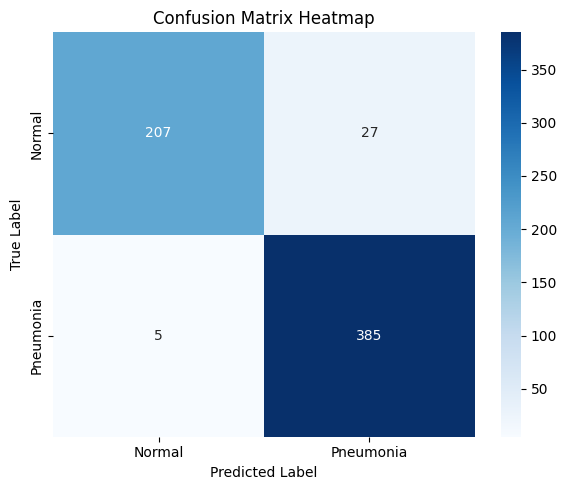

In [21]:
# Cell 7: test evaluation and confusion matrix + heatmap
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

if test_loader:
    model.eval()
    ys = []
    ps = []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader):
            inputs = inputs.to(DEVICE)
            out = model(inputs)

            if BINARY:
                probs = out.cpu().numpy().squeeze()
                preds = (probs >= 0.5).astype(int)
                ps.extend(preds.tolist())
            else:
                probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
                preds = np.argmax(out.cpu().numpy(), axis=1)
                ps.extend(preds.tolist())

            ys.extend(labels.numpy().tolist())

    # Print classification report
    print(classification_report(ys, ps))

    # Confusion matrix
    cm = confusion_matrix(ys, ps)
    print("Confusion matrix:\n", cm)

    # --- Heatmap ---
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Pneumonia"],
                yticklabels=["Normal", "Pneumonia"])
    plt.title("Confusion Matrix Heatmap")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

else:
    print("No test_loader found; skip test evaluation.")


In [24]:
# Cell 8: export TorchScript
model.eval()
example = torch.randn(1, 3, INPUT_SIZE[0], INPUT_SIZE[1]).to(DEVICE)
# If your model expects channels-last, you may need to adapt. This code assumes CHW tensors (torchvision style).
try:
    traced = torch.jit.trace(model, example)
    traced.save("pneumonia_ts.pt")
    print("Saved TorchScript model: pneumonia_ts.pt")
except Exception as e:
    print("TorchScript trace failed:", e)


Saved TorchScript model: pneumonia_ts.pt


In [25]:
# Cell 9: inference helper (load model weights and predict)
from torchvision import transforms

def load_model_for_inference(weights_path="pneumonia_pt.pth", device=DEVICE):
    m = create_model(num_classes=num_out, pretrained=False, backbone="mobilenetv2")
    m.load_state_dict(torch.load(weights_path, map_location=device))
    m.to(device).eval()
    return m

infer_transforms = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def predict_pil(model, pil_img):
    img = pil_img.convert("RGB")
    x = infer_transforms(img).unsqueeze(0).to(DEVICE)  # 1,C,H,W
    with torch.no_grad():
        out = model(x)
        if BINARY:
            prob = out.cpu().numpy().squeeze().item()
        else:
            prob = torch.softmax(out, dim=1)[:,1].cpu().numpy().squeeze().item()
    return prob

# Example quick test:
m_inf = load_model_for_inference("pneumonia_pt.pth", DEVICE)
# from PIL import Image
# img = Image.open("/path/to/example.jpg")
# print("prob:", predict_pil(m_inf, img))


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [26]:
# Cell 10: Gradio UI to test model quickly
import gradio as gr
from PIL import Image
m_inf = load_model_for_inference("pneumonia_pt.pth", DEVICE)

def gradio_predict(img: Image.Image):
    p = predict_pil(m_inf, img)
    return {"Pneumonia probability": float(p)}

iface = gr.Interface(fn=gradio_predict,
                     inputs=gr.Image(type="pil"),
                     outputs=gr.Label(),
                     title="Pneumonia detector (PyTorch)")
iface.launch(share=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://113e73f0be40bf5c0f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
